# 03 — Forecast (SARIMA), and where it fails

A seasonal ARIMA forecast of monthly national power-sector CO₂ on the real 96-month series
(Jan 2018 – Dec 2025), plus two backtests. The first is in-distribution. The **second is
deliberately run across the 2020 COVID demand collapse** — a genuine structural break in the
data — and is the point of the notebook: it shows, on real data, that a historical-trend
model cannot see a regime change coming.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB = os.path.join("..", "malaysia_power.db")
OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)
assert os.path.exists(DB), "run `python scripts/build_db.py` from the repo root first"

con = sqlite3.connect(DB)
gen = pd.read_sql_query(
    """SELECT m.month_id, m.year, m.month, m.month_start, f.fuel_name,
              g.twh, g.share_pct, e.mtco2
       FROM fact_generation_monthly g
       JOIN dim_month m USING(month_id)
       JOIN dim_fuel  f USING(fuel_id)
       JOIN fact_emissions_monthly e USING(month_id, fuel_id)""", con)
summ = pd.read_sql_query(
    """SELECT m.month_id, m.year, m.month, m.month_start,
              s.total_gen_twh, s.total_emissions_mtco2, s.co2_intensity_g_per_kwh,
              d.demand_twh, d.net_imports_twh
       FROM fact_summary_monthly s
       JOIN dim_month m USING(month_id)
       JOIN fact_demand_monthly d USING(month_id)""", con)
con.close()
gen["date"] = pd.to_datetime(gen["month_start"])
summ["date"] = pd.to_datetime(summ["month_start"])
FUEL_ORDER = ["Coal", "Gas", "Other Fossil", "Hydro", "Bioenergy", "Solar"]
FUEL_COLOR = {"Coal": "#3f3f46", "Gas": "#f59e0b", "Other Fossil": "#a16207",
              "Hydro": "#2563eb", "Bioenergy": "#16a34a", "Solar": "#fbbf24"}
print(f"{gen.month_id.nunique()} months {gen.year.min()}-{gen.year.max()}, {gen.fuel_name.nunique()} fuels")

96 months 2018-2025, 6 fuels


96 months, 2018-01 .. 2025-12
count    96.00
mean      9.20
std       0.64
min       7.53
25%       8.81
50%       9.23
75%       9.59
max      10.56


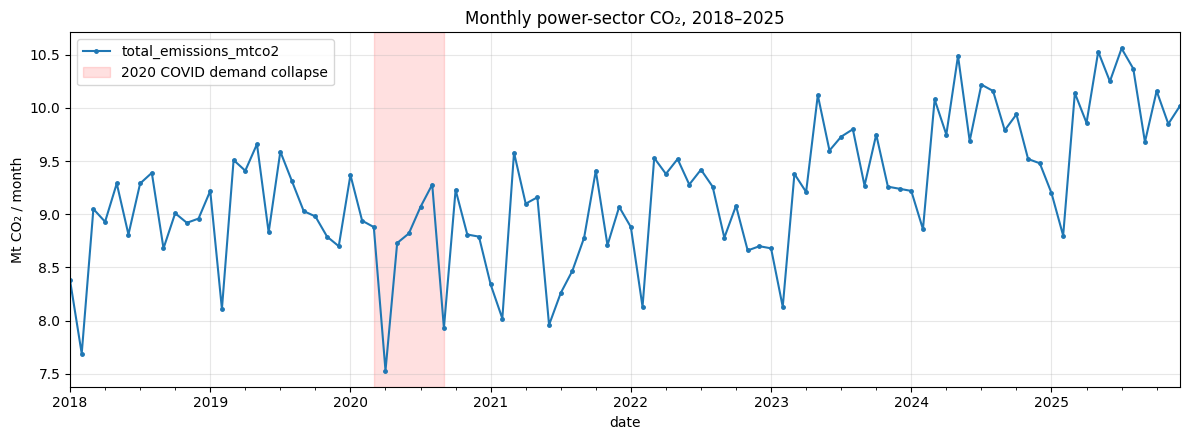

In [2]:
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.statespace.sarimax import SARIMAX

series = summ.set_index("date").sort_index()["total_emissions_mtco2"].asfreq("MS")
print(f"{len(series)} months, {series.index.min():%Y-%m} .. {series.index.max():%Y-%m}")
print(series.describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 4.5))
series.plot(ax=ax, marker="o", ms=2.5)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-09-01"), color="red", alpha=0.12, label="2020 COVID demand collapse")
ax.set_ylabel("Mt CO₂ / month"); ax.set_title("Monthly power-sector CO₂, 2018–2025")
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

### Model order: SARIMA(1,1,1)(1,1,1,12)

`d=1` for the trend in the level; `D=1, s=12` for the annual pattern; `p=q=1` and `P=Q=1`
for short-run and seasonal residual structure. With 96 monthly observations this order is
comfortably identifiable. The order is fixed (not searched) on purpose — over-tuning the
order on a short series is its own mistake; the interest here is the forecast's behaviour,
including its failure mode, not squeezing the last point of in-sample fit.

In [3]:
ORDER, SEASONAL = (1, 1, 1), (1, 1, 1, 12)
def fit_sarima(tr): return SARIMAX(tr, order=ORDER, seasonal_order=SEASONAL,
                                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
def metrics(a, p):
    a, p = np.asarray(a, float), np.asarray(p, float)
    return dict(MAPE_pct=float(np.mean(np.abs((a - p) / a)) * 100),
                RMSE_Mt=float(np.sqrt(np.mean((a - p) ** 2))),
                mean_bias_Mt=float(np.mean(p - a)))

# Backtest 1 -- in-distribution: train 2018-2023, test 2024
tr1, te1 = series[:"2023-12"], series["2024-01":"2024-12"]
f1 = fit_sarima(tr1); p1 = f1.get_forecast(len(te1)).predicted_mean; p1.index = te1.index
m1 = metrics(te1, p1)

# Backtest 2 -- structural break: train 2018-2019, test 2020 (the COVID year)
tr2, te2 = series[:"2019-12"], series["2020-01":"2020-12"]
f2 = fit_sarima(tr2); p2 = f2.get_forecast(len(te2)).predicted_mean; p2.index = te2.index
m2 = metrics(te2, p2)

print("Backtest 1  (train 2018-2023, test 2024)      :", {k: round(v, 3) for k, v in m1.items()})
print("Backtest 2  (train 2018-2019, test 2020/COVID):", {k: round(v, 3) for k, v in m2.items()})
mdf = pd.DataFrame({"backtest_1_in_distribution": m1, "backtest_2_covid_2020": m2}).T.round(3)
mdf.to_csv(os.path.join(OUT, "forecast_metrics.csv"))
print("\nwrote outputs/forecast_metrics.csv")
print(mdf.to_string())

Backtest 1  (train 2018-2023, test 2024)      : {'MAPE_pct': 5.21, 'RMSE_Mt': 0.576, 'mean_bias_Mt': -0.501}
Backtest 2  (train 2018-2019, test 2020/COVID): {'MAPE_pct': 6.756, 'RMSE_Mt': 0.709, 'mean_bias_Mt': 0.096}

wrote outputs/forecast_metrics.csv
                            MAPE_pct  RMSE_Mt  mean_bias_Mt
backtest_1_in_distribution     5.210    0.576        -0.501
backtest_2_covid_2020          6.756    0.709         0.096


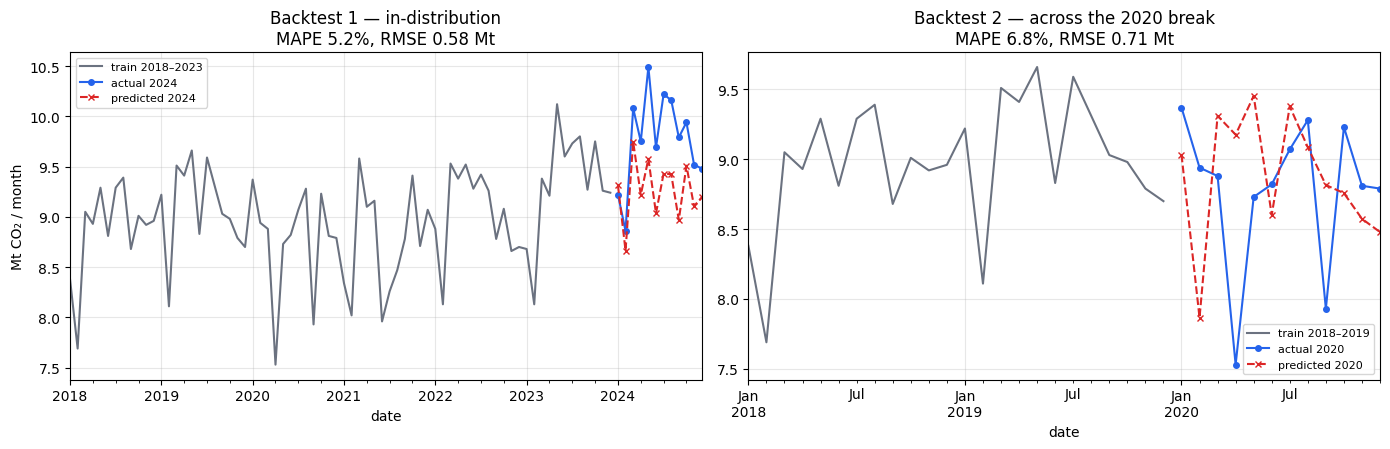

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=False)
ax = axes[0]
series[:"2023-12"].plot(ax=ax, color="#6b7280", label="train 2018–2023")
te1.plot(ax=ax, color="#2563eb", marker="o", ms=4, label="actual 2024")
p1.plot(ax=ax, color="#dc2626", ls="--", marker="x", ms=5, label="predicted 2024")
ax.set_title(f"Backtest 1 — in-distribution\nMAPE {m1['MAPE_pct']:.1f}%, RMSE {m1['RMSE_Mt']:.2f} Mt")
ax.set_ylabel("Mt CO₂ / month"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
series[:"2019-12"].plot(ax=ax, color="#6b7280", label="train 2018–2019")
te2.plot(ax=ax, color="#2563eb", marker="o", ms=4, label="actual 2020")
p2.plot(ax=ax, color="#dc2626", ls="--", marker="x", ms=5, label="predicted 2020")
ax.set_title(f"Backtest 2 — across the 2020 break\nMAPE {m2['MAPE_pct']:.1f}%, RMSE {m2['RMSE_Mt']:.2f} Mt")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(OUT, "forecast_backtest.png"), dpi=130); plt.show()

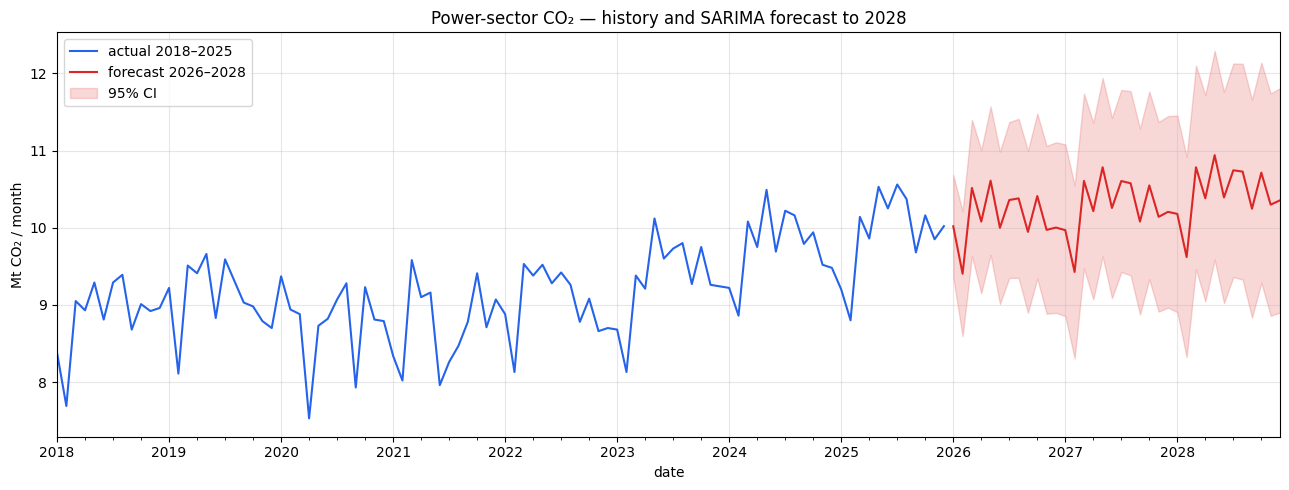

Forecast annual national power-sector CO2 (Mt), 95% CI:
  2026: 121.7  [110.1, 133.3]
  2027: 123.4  [109.3, 137.5]
  2028: 125.4  [108.9, 141.8]

(historical, for comparison):
  2018: 106.4
  2019: 109.1
  2020: 105.4
  2021: 104.9
  2022: 108.6
  2023: 112.2
  2024: 117.2
  2025: 119.4


In [5]:
# Forward forecast: retrain on the full series, project 2026-2028 with 95% CI
ff = fit_sarima(series)
fcst = ff.get_forecast(36); mean_fc = fcst.predicted_mean
ci = fcst.conf_int(alpha=0.05); ci.columns = ["lo", "hi"]
idx = pd.date_range("2026-01-01", periods=36, freq="MS"); mean_fc.index, ci.index = idx, idx

fig, ax = plt.subplots(figsize=(13, 5))
series.plot(ax=ax, color="#2563eb", label="actual 2018–2025")
mean_fc.plot(ax=ax, color="#dc2626", label="forecast 2026–2028")
ax.fill_between(ci.index, ci.lo, ci.hi, color="#dc2626", alpha=0.18, label="95% CI")
ax.set_ylabel("Mt CO₂ / month"); ax.set_title("Power-sector CO₂ — history and SARIMA forecast to 2028")
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
fig.savefig(os.path.join(OUT, "forecast_2026_2028.png"), dpi=130); plt.show()

fdf = pd.DataFrame({"mean": mean_fc, "lo": ci.lo, "hi": ci.hi}); fdf["year"] = fdf.index.year
af = fdf.groupby("year").sum().round(1)
print("Forecast annual national power-sector CO2 (Mt), 95% CI:")
for y, r in af.iterrows():
    print(f"  {y}: {r['mean']:.1f}  [{r['lo']:.1f}, {r['hi']:.1f}]")
hist = series.groupby(series.index.year).sum().round(1)
print("\n(historical, for comparison):")
for y, v in hist.items():
    print(f"  {y}: {v:.1f}")

## Interpreting the two backtests

Neither backtest blows up — but both miss real structural movements, in ways that say what
the model class can and can't do.

Backtest 1 (train 2018–2023, test 2024): MAPE ≈ 5%, and a *negative* bias of about half a
megatonne per month — the model trained through 2023 systematically under-predicts 2024,
because 2024 generation jumped (data-centre load ramping) faster than the prior trend implied.
It didn't see the demand surge.

Backtest 2 (train 2018–2019, test 2020): MAPE ≈ 7%, with the largest errors in April–June —
the model carries the 2018–19 trend and seasonality straight through the COVID lockdown and
never anticipates the dip, because a SARIMA model assumes a stable data-generating process.
At the *annual* level the miss partly washes out (2020's total landed near the extrapolation),
which is itself instructive: a structural break can be invisible in annual aggregates and still
be there in the months.

So the 5–7% errors are the honest accuracy of trend extrapolation on a real grid — an order of
magnitude worse than a model would look on a smooth, near-deterministic series, and the gap is
where the structural shocks live. The forecast to 2028 (emissions drifting up to ≈125 Mt) is
worth less than that gap: Malaysia's power system has the 2026 carbon tax, the National Energy
Transition Roadmap, fast-growing data-centre load and EV adoption ahead of it, and a model
trained on historical aggregates treats every one of those as noise until after the fact. A
scenario-conditioned model — one that takes policy and demand-driver choices as *inputs* — is
the right next instrument, not a better-tuned extrapolation.